**Import Functions**

The file "CM_and_CS_graph_state_exploration_functions.py" contains functions for working with complete multipartite and clique-star graphs, and their local complements. Specify the path directory as needed as important everything from this file.

In [1]:
!cp drive/MyDrive/Colab\ Notebooks/CM_and_CS_graph_state_exploration_functions.py .
!cp drive/MyDrive/Colab\ Notebooks/graph.py .
!cp drive/MyDrive/Colab\ Notebooks/qasst.py .
!cp drive/MyDrive/Colab\ Notebooks/random_DH_graphs.py .

In [2]:
from CM_and_CS_graph_state_exploration_functions import *
from graph import *
from qasst import *
from random_DH_graphs import *

**Build a random graph**

Build a random graph $G$ which is either complete multipartite or a clique-star based on the following parameters.
*   n: number of vertices (must be at least 6 or greater)
*   type: "CM" for complete multipartite or "CS" for clique star
*   ni_min: the smallest "group size" for vertices from the same quotient graph (must be at least 2 or greater)
*   k_min: the minimum number of quotient graphs $Q_1,\cdots,Q_k$ in the QASST decomposition of $G$, excluding the central $Q_0$ ($k$ must be at least 3 or greater).
*   k_max: the maximum number of quotient graphs (equal to or larger than k_min)

Subject to these paramters, the function generates a random QASST decomposition for $G$, builds up each quotient graph $Q_1,\cdots,Q_k$, and then combines these into to the target graph $G$.

The function outputs three things:
*   G: a NetworkX graph object corresponding to the randomly generated graph.
*   G_size_list: a Python list of group sizes $[n_1,\cdots,n_k]$ forming an integer partition of the total number of vertices $n$. These represent the subsets of vertices contained in each quotient graph.
*   G_qasst_dict: a Python dictionary describing the structure of the QASST decomposition. Keys are strings of the form "Q0", "Q1", ... , "Qk" and values are strings of three types: "c" for complete, "ss" for star-spoke, or "sc" for star-center (possibly with an index for "Q0"). See the preprint for detailed explanations of these.











In [3]:
G, G_size_list, G_qasst_dict = build_random_CM_or_CS_lc_equivalent_graph(n=6,type="CM",ni_min=2,k_min=3,k_max=6)

In [4]:
len(G.edges), G_size_list, G_qasst_dict

(7, [2, 2, 2], {'Q0': 'c', 'Q1': 'ss', 'Q2': 'sc', 'Q3': 'ss'})

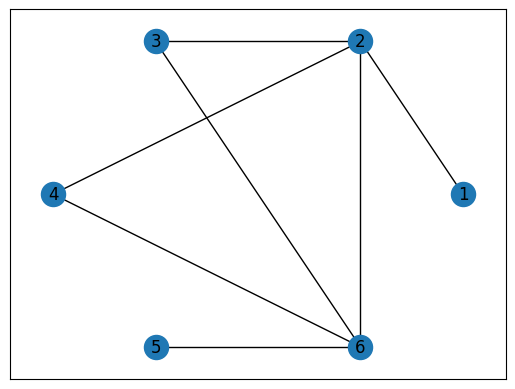

In [5]:
nx.draw_networkx(G,pos=nx.circular_layout(G),with_labels=True)

**Determine LC Orbit Size**

For either the complete multipartite ("CM") or clique-star ("CS") case, the size of the LC orbit (that is, the total number of graphs locally equivalent to the given one) can be determined by an analytical formula.

In [6]:
determine_LC_orbit_size_for_CM_or_CS(G_size_list,"CM")

40

**Minimize across LC Orbit**

Based on analytical formulas (fully derived in the preprint), we may identify constructions for locally equivalent graphs which are minimal edge or minimal $\Delta G$ across the LC orbit. We only need to know the list of group sizes $[n_1,\cdots,n_k]$ (provide as input) and whether the graph is in the LC orbit of the complete multipartite graph or a clique-star (specified by function).

Each of these functions returns two things:
*   min_E or min_delta_G: the minimal value of the specified parameter across the LC orbit
*   opt_qasst_dict: a dictionary representing the QASST decomposition of this optimized graph. This can be used to reconstruct the graph if needed.



In [7]:
#min_E, opt_qasst_dict = minimal_edge_count_and_structure_clique_star_orbit(G_size_list)
min_E, opt_qasst_dict = minimal_edge_count_and_structure_complete_multipartite_orbit(G_size_list)

min_E, opt_qasst_dict

(6, {'Q0': 'sc1', 'Q1': 'sc', 'Q2': 'ss', 'Q3': 'ss'})

In [8]:
#min_delta_G, opt_qasst_dict = determine_minimal_Delta_G_clique_star(G_size_list)
min_delta_G, opt_qasst_dict = determine_minimal_Delta_G_complete_multipartite(G_size_list)

min_delta_G, opt_qasst_dict

(3, {'Q0': 'sc1', 'Q1': 'sc', 'Q2': 'ss', 'Q3': 'ss'})

**Compute Split-Fuse Parameters**

The spit-fuse method is an alternative protocol for preparing the graph state corresponding to a distance-hereditary graph. The number CZ gates (edges), number of time steps or circuit depth ($\Delta G+1$), total number of qubits (vertices), and the subset of auxillary qubits can all be inferred from the list of group sizes $[n_1,\cdots,n_k]$ in the complete multipartite or clique-star cases. In some cases, these parameters may be superior to direction implementation of an optimal LC-equivalent graph state.

In [9]:
sf_CZ, sf_time, sf_qubits, sf_aux = compute_split_fuse_parameters_for_complete_multipartite(G_size_list)
sf_CZ, sf_time, sf_qubits, sf_aux

(11, 4, 12, 6)

**Find Explicit LC Sequence**

If a given graph is locally equivalent to a complete multipartite graph or a clique star, then we can obtain a sequence of LC operations which transforms $K_{n_1,\cdots,n_k}$ or $CS^1_{n_1,\cdots,n_k}$ into the given graph. The function "find_LC_transformation_for_graph()" identifies the equivalence class ("CM" or complete multipartite) or ("CS" or clique-star), along with an explicit sequence of vertices on which to perform the LC operations. These are stored as a list $[v_1,\cdots,v_k]$.

A "human-readable" version of this list in function composition notation can also be computed with the same information as this list. This is generated using the "write_pretting_LC_trasnformation()" function.

In [10]:
G_type, LC_seq = find_LC_transformation_for_graph(G_size_list,G_qasst_dict)
G_type, LC_seq

Graph is LC equivalent to complete multipartite.
LC transformation from Kn1,...,nk to graph:


('CM', [1, 5, 1])

In [11]:
# Function composition expression of the LC sequence
write_pretty_LC_transformation(G_type,LC_seq)

LC transformation from Kn1,...,nk to graph:


'c1 o c5 o c1'

**Apply Primitive Local Complement**

To apply a primitive local complement on a NetworkX graph $G$, one can use the "primitive_local_complement(G,v)" function, taking $G$ and a choice of vertex $v$ as input. A sequence of local complements can be applied by using primitive local complements iteratively.

In [12]:
G3 = primitive_local_complement(G,1)

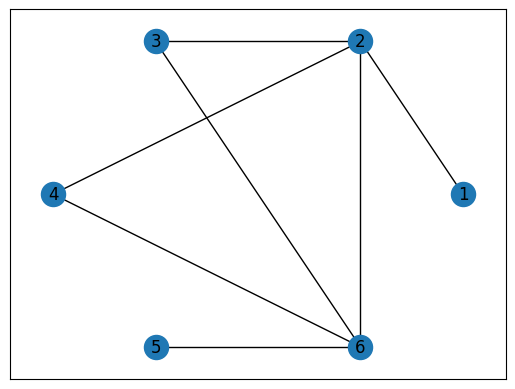

In [13]:
nx.draw_networkx(G3,pos=nx.circular_layout(G3),with_labels=True)

**Infer Local Clifford Operations**

A sequence of local complement operations on a graph corresponds to a sequence of local-Clifford operations on the corresponding graph states. These involve operations on neighbors as well as the vertices LC is applied to. We can identify the sequence of local-Clifford operations from a given graph state (as a NetworkX graph object) to a target graph state based on the sequence of local complements. This is computed and returned as a list of dictionaries. Each entry in the list corresponds to one LC operation, and the corresponding dictionary consists of keys corresponding to vertex (qubit) labels with values corresponding to local Clifford operations (this includes the identity operation for qubits not in the neighborhood).

For example, for the randomly constructed graph $G$ obtained earlier, we can identify the sequence of local clifford operations that convert it back to the complete multipartite graph (or clique-star) by reversing the LC-sequence obtained above.

In [14]:
G2, G2_LC_list_of_dicts = compute_local_Clifford_transformation_and_state(G,LC_seq[::-1])

In [15]:
G2_LC_list_of_dicts

[{1: 'X(-pi/4)', 2: 'Z(pi/4)', 3: 'I', 4: 'I', 5: 'I', 6: 'I'},
 {1: 'I', 2: 'I', 3: 'I', 4: 'I', 5: 'X(-pi/4)', 6: 'Z(pi/4)'},
 {1: 'X(-pi/4)', 2: 'Z(pi/4)', 3: 'I', 4: 'I', 5: 'I', 6: 'I'}]

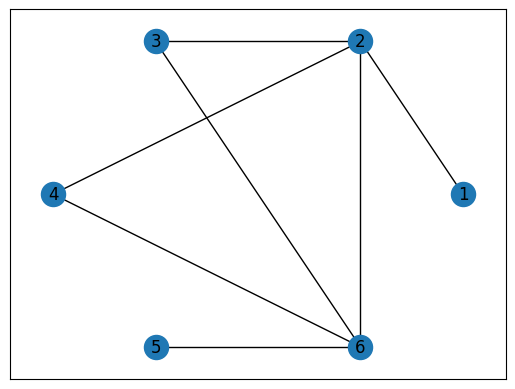

In [16]:
nx.draw_networkx(G2,pos=nx.circular_layout(G2),with_labels=True)

**Construct Random Distance-Hereditary Graph**

Build a random distance-hereditary graph $G$ as a NetworkX graph object along with its QASST, a NetworkX graph oject whose nodes are represented by quotient graphs (also NetworkX graph ojects). $G$ is constructed recursively using a random sequence of one-vertex extensions by twins (pendant vertex, false twin, or true twin). The user needs only specify the number of desired vertices.

In [17]:
G_DH_sample, G_DH_sample_qasst = create_random_DH_graph_and_QASST(10)

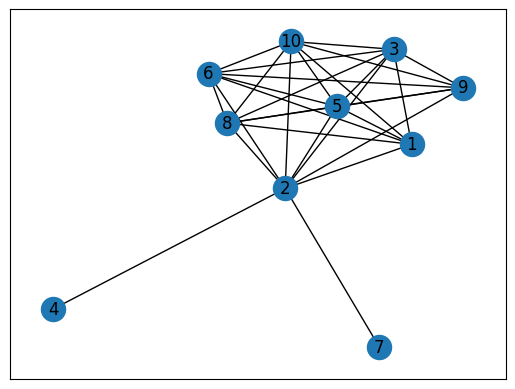

In [18]:
nx.draw_networkx(G_DH_sample)

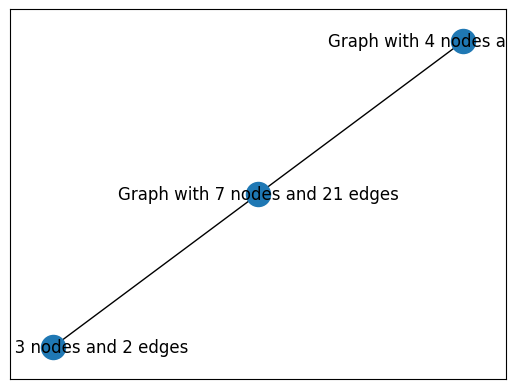

In [19]:
nx.draw_networkx(G_DH_sample_qasst)

**Construct Random Graph and Compute its QASST**

Generate a random graph with the specified number of nodes $n$ and edge density $p$ (a value between 0 and 1). Generate the QASST of this graph by computing its split decomposition. This is slow and will take time for graphs with more than about 20 vertices.


In [20]:
G_random = generate_connected_graph(n=10,p=0.8)
G_random_qasst = build_qasst(G_random)

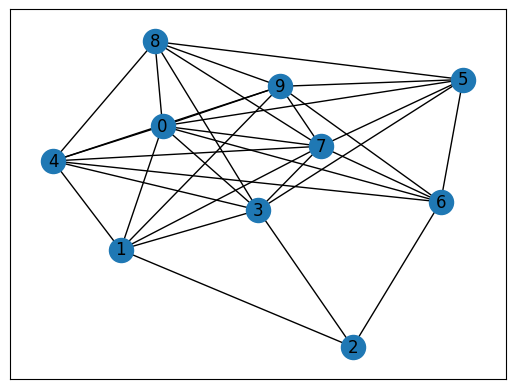

In [21]:
nx.draw_networkx(G_random)

<Figure size 700x400 with 0 Axes>

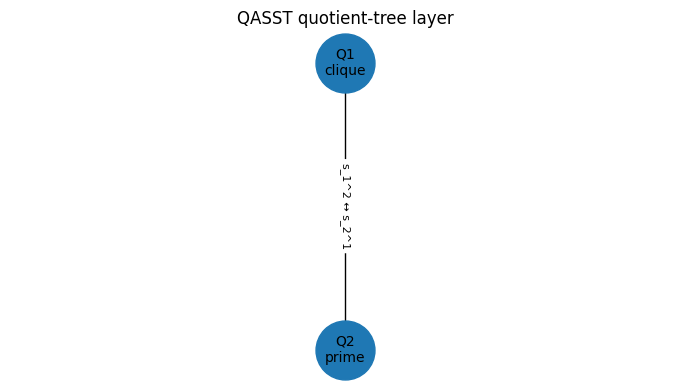

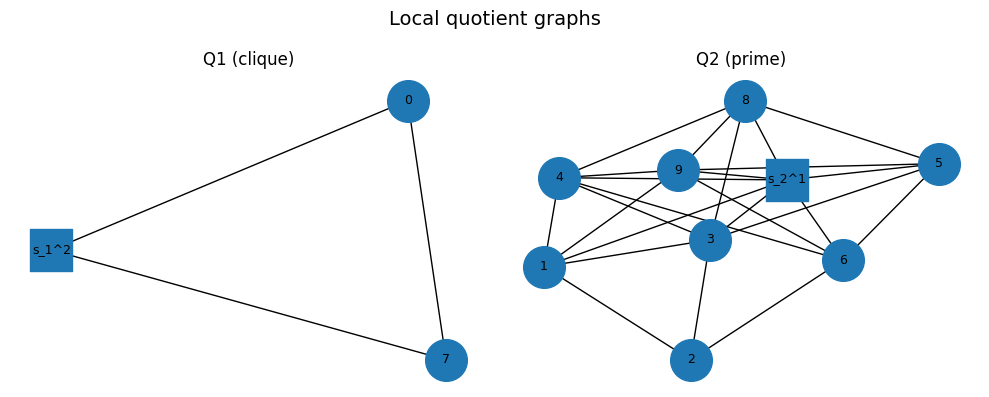

<Figure size 1100x700 with 0 Axes>

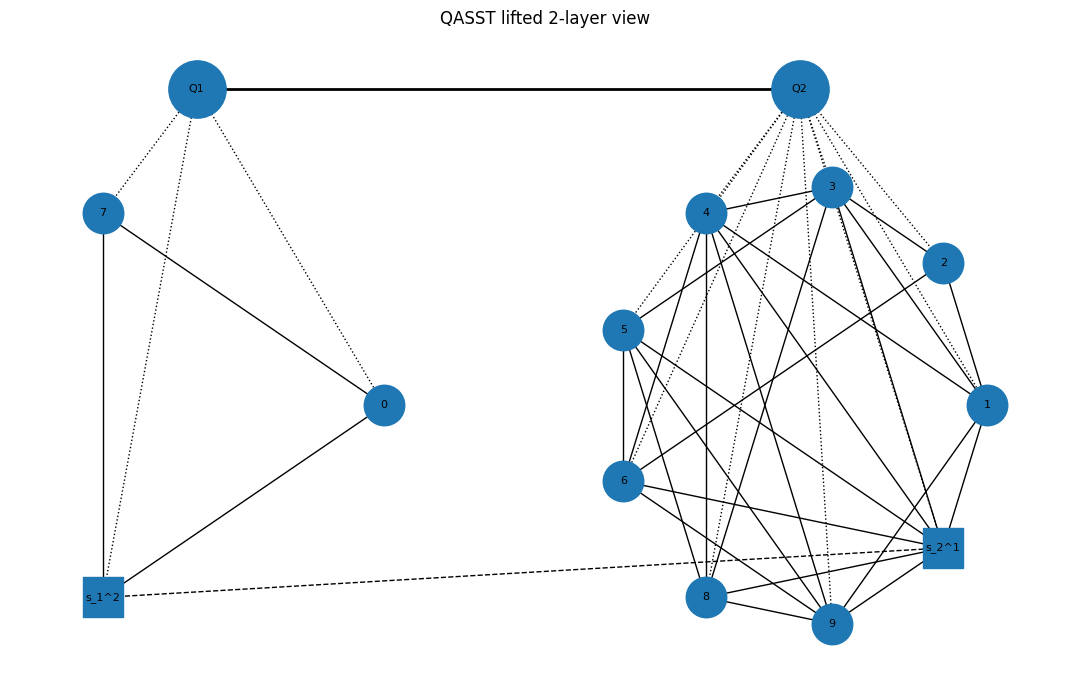

In [22]:
show_qasst(G_random_qasst)

**Comparison of Graph State Preparation Techniques**

Run numerical simulations to compare the resources (number of CZ gates or circuit depth) required to construct randomly generated graphs of various classes. These include randomly generated graphs taken from the LC orbit of a complete multipartite graph or clique-star, randomly generated distance-hereditary graphs, or generic randomly generated graphs of a specified edge density.

Function input parameters:


*   type_input: "CM" for complete multipartite or "CS" for clique-star (only for the first case)
*   edge_density: a value between 0 and 1 representing the density of edges in a generic randomly generated graph (only for the third case)
*   n_min: the minimum number of vertices (qubits) in a randomly generated graph state
*   n_max: the maximum number of vertices (qubits) in a randomly generated graph state
*   n_step: the step size between sizes of randonly generated graph states; it will increase from n_min in steps of this size until reaching n_max
*   sample_size: the number of randomly generated graphs to use for each fixed graph size

The function will return two graphs showing a range of boxplots comparing the various preparation methods.







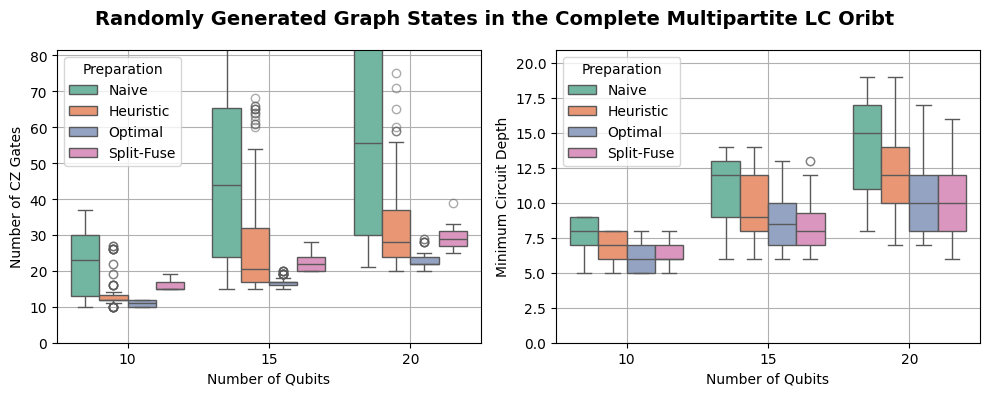

In [23]:
generate_and_plot_CM_or_CS_optimization_data(type_input="CM", n_min=10, n_max=20, n_step=5, sample_size=100)

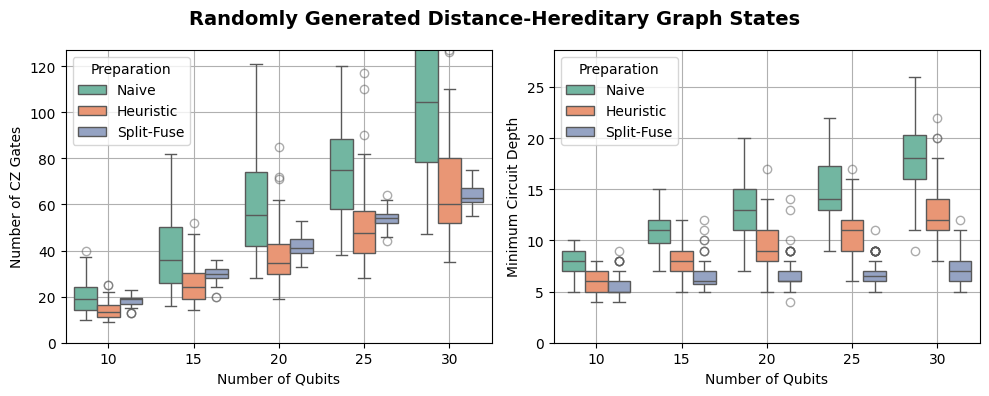

In [24]:
generate_and_plot_random_DH_optimization_data(n_min=10, n_max=30, n_step=5, sample_size=100)

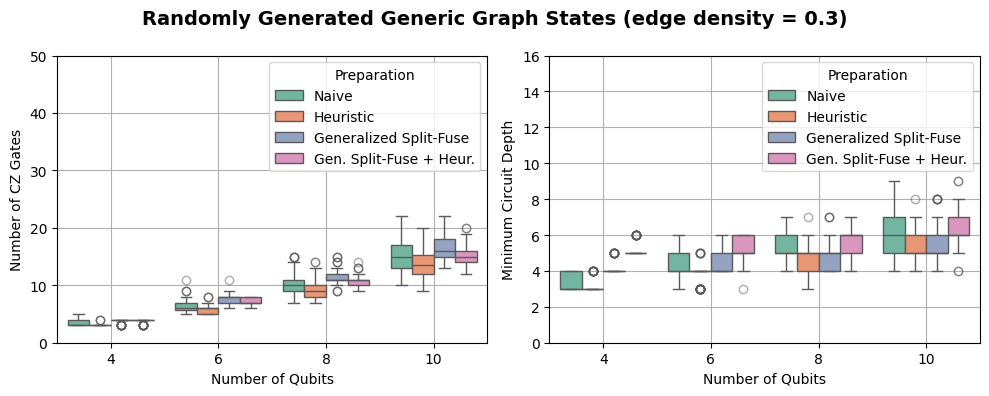

In [25]:
generate_and_plot_generic_random_graph_optimization_data(edge_density=0.3, n_min=4, n_max=10, n_step=2, sample_size=100)